### Goal

Build a neural network that can recognize handwritten digits (0–9).

Example:

Image of a handwritten digit

        ↓

Neural Network

        ↓

Predicts: 7

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten 

mnist-TensorFlow already provides the dataset.So no Kaggle download is needed.

Sequential-This creates the neural network.

A Dense layer means:
Every neuron is connected to every neuron in the next layer.
Use Dense when building a normal neural network.

Flatten-
This converts an image into a single row.We use it only when the input is an image.
Example:
28 × 28 image
↓

784 numbers

Neural networks expect a 1D vector.

If you're using your own dataset (Kaggle, CSV, images), you won't use:
from tensorflow.keras.datasets import mnist
You'll load it yourself.

Is Sequential always written?
It is used when your network is simple:

Input
   ↓
Hidden
   ↓
Hidden
   ↓
Output

This is called a Sequential Model.

More complex networks (ResNet, U-Net, GANs, etc.) use the Functional API instead.

For beginners, 90% of projects use Sequential.


In [3]:
#This is simply TensorFlow/Keras's syntax for loading its built-in datasets.

(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


60,000 training images, each 28×28 pixels
10,000 test images, each 28×28 pixels
X_train → 60,000 handwritten images
y_train → the correct digit for each image
X_test → 10,000 unseen images
y_test → correct answers for those test images
28 × 28 → each image has 28 rows × 28 columns of pixels

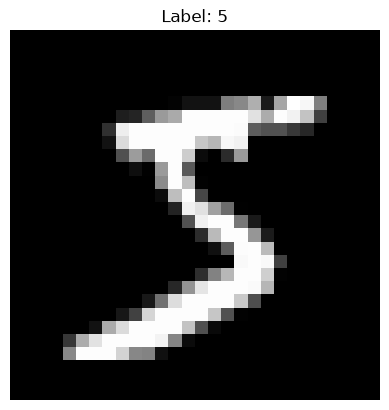

In [5]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

X_train[0] → the 28×28 pixel image
y_train[0] → 5, the correct label

Imagine the image as a grid

It is:

28 columns
↓
□□□□□□□□□□□□□□...
□□□□□□□□□□□□□□...
□□□□□□□□□□□□□□...
...
28 rows

So there are:

28 × 28 = 784 tiny squares.

Each tiny square is called a pixel.

Now what is inside one square?

Each square has a number.

For example:

Black square → 0
Gray square  → 100
White square → 255

So your image is actually:

[0, 0, 0, 15, 80, 200, 255, ...]

There are 784 such numbers.

That's what this means:

The image is represented by 784 numbers.

Now why /255?

We currently have numbers like:

0, 50, 100, 150, 200, 255

We simply make them smaller:

0/255   = 0
50/255  = 0.196
100/255 = 0.392
150/255 = 0.588
200/255 = 0.784
255/255 = 1
We are only changing the numbers representing the pixels from a 0–255 scale to a 0–1 scale.
X_train = X_train / 255.0
simply means:

"Take every pixel number and divide it by 255 so that every pixel lies between 0 and 1."
0 = black, 255 = white, and values in between are shades of gray.

In [6]:
#normalize the pixel values
X_train=X_train / 255.0
X_test=X_test/255.0

In [7]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

r:\C\PYTHON PROGRAMS\Deep Learning project 1\.venv-1\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


So Flatten changes:
28 × 28
   ↓
784

It does not change the pixel values.
It only changes their arrangement/shape.


First hidden layer-
Dense(128,activation='relu')
This creates 128 neurons.

Each neuron receives the 784 pixel values and learns different combinations/patterns from them.

relu is the activation function.
ReLU helps the network learn non-linear patterns instead of behaving like one simple linear calculation.

Second hidden layer-Dense(64, activation='relu') Another layer, this time with 64 neurons.

Hidden Layer 1 → 128 neurons
Hidden Layer 2 → 64 neurons

The network does NOT automatically decide this. We designed this architecture.


Output layer- Dense(10, activation='softmax')

Why 10?

Because MNIST has exactly 10 possible digits:

0 1 2 3 4 5 6 7 8 9

Therefore we need 10 output neurons.

Each output represents the model's probability for one digit:

0 → 0.01
1 → 0.02
2 → 0.03
3 → 0.01
4 → 0.04
5 → 0.82  ← highest
6 → 0.01
7 → 0.02
8 → 0.02
9 → 0.02

The probabilities add up to 1.

So the model would predict:

5

because 5 has the highest probability.

softmax is what converts the final outputs into these probabilities.

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Flatten simply rearranges the 28×28 pixels into one list of 784 numbers.
None in the output shape:means batch size is not fixed yet. It could receive 32 images, 64 images, 100 images, etc.

Flatten Layer: Converts each 28 × 28 image into a one-dimensional vector of 784 pixel values (28 × 28 = 784). It has 0 parameters because it only changes the shape of the data and does not learn anything.

First Dense Layer: Contains 128 neurons with the ReLU activation function. It receives 784 inputs. The number of trainable parameters is 784 × 128 + 128 = 100,480 (weights plus biases).

Second Dense Layer: Contains 64 neurons with ReLU activation. It receives 128 inputs from the previous layer. Trainable parameters are 128 × 64 + 64 = 8,256.

Output Layer: Contains 10 neurons, one for each digit from 0 to 9, and uses the Softmax activation function to produce probabilities for each class. Trainable parameters are 64 × 10 + 10 = 650.


The network has a total of 109,386 trainable parameters (100,480 + 8,256 + 650). These parameters (weights and biases) are adjusted during training so that the network learns to recognize handwritten digits.


Why does the second layer receive 128 inputs?
Because 100,480 is the number of parameters, not the output.

The first layer uses 784 inputs and produces 128 outputs.
So the second layer receives those 128 output values as its inputs.
It is not 100,480 values being passed forward.

Same image:
784 pixels
   ↓
   ├── Neuron 1 → has its own 784 weights → activation 1
   ├── Neuron 2 → has its own 784 weights → activation 2
   ├── Neuron 3 → has its own 784 weights → activation 3
   ...
   └── Neuron 128 → has its own 784 weights → activation 128

   Because each neuron is trying to learn a different pattern from the same image.

For example, very roughly:
Neuron 1 might learn something about a vertical stroke.
Neuron 2 might learn something about a curved region.
Neuron 3 might learn another pattern.

The weights are internal learnable numbers created by the neural network. They are not part of the image.
If neuron 1 is learning a vertical-stroke pattern, it may learn:

pixels belonging to that stroke → larger weights
other pixels → smaller/negative weights

all 128 neurons produce an activation, and those 128 activation values become the inputs to the next layer.
For Neuron 1:
784 inputs
   ↓
each input × its corresponding weight
   ↓
add all 784 results
   ↓
+ bias
   ↓
activation function (ReLU)
   ↓
Neuron 1's output

 (w1x1 + w2x2 +.... + wnxn) + b). This value is passed to an activation function to decide if the neuron fires.
 ✅ X1, X2, ..., X784 are the 784 input pixel values.

 The network doesn't decide "input 2 is important, therefore increase its weight" manually. Backpropagation + gradient descent automatically adjust the weight based on how much it helps reduce the prediction error.

 Each neuron learns to detect certain patterns/features in the input. It produces an activation value representing how strongly that pattern is present. All 128 activation values are passed to the next layer, but their strengths can differ depending on how strongly each learned feature is detected.

 Each neuron learns to detect a particular pattern/feature, but we don't manually assign which feature it will detect.And the network automatically learns what patterns each neuron responds to through training.

In [10]:
#Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

input
 ↓
weights
 ↓
prediction
 ↓
compare with correct answer
 ↓
error
 ↓
backpropagation
 ↓
update weights

What is compile()?
So far, we have only built the neural network architecture:
But the model still doesn't know:

How should I change my weights?
How should I measure my mistake?
What should I track while learning?

compile() gives the model those instructions.

optimizer='adam'
The optimizer controls how the weights and biases are updated during training.
The optimizer decides how those weights should be adjusted based on the error.
Adam is one popular ,common,default optimization algorithm Adam helps the network learn by updating its weights and biases.


loss='sparse_categorical_crossentropy'
The loss function measures how wrong the prediction is.
for eg 5 → 0.02
       7 → 0.80
That's a bad prediction because the actual answer was 5.
The loss function converts this difference into a numerical error value.

sparse_categorical_crossentropy is a loss function/method for measuring prediction error. 

metrics=['accuracy']
This tells the model:
"While training, also show me the percentage of predictions that are correct.


So compile() doesn't train the model.It prepares the model for training by specifying:
Optimizer → HOW to update weights
Loss      → HOW to measure error
Accuracy  → WHAT performance metric to show

In [11]:
#Training

history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9199 - loss: 0.2699 - val_accuracy: 0.9597 - val_loss: 0.1421
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9667 - loss: 0.1125 - val_accuracy: 0.9697 - val_loss: 0.1025
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9747 - loss: 0.0810 - val_accuracy: 0.9678 - val_loss: 0.1103
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9808 - loss: 0.0587 - val_accuracy: 0.9722 - val_loss: 0.0953
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9840 - loss: 0.0495 - val_accuracy: 0.9722 - val_loss: 0.0970
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9880 - loss: 0.0370 - val_accuracy: 0.9699 - val_loss: 0.1107
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.0297 - val_accuracy: 0.9742 - val_loss: 0.0944
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9906 - loss: 0.0278 - 

model.fit()
Means: train the neural network using the given data.

X_train
Our 60,000 images (the inputs).

y_train
The correct answers for those images


The model compares its prediction with these correct answers and uses the error to update its weights.

epochs=10
One epoch = the model sees the entire training dataset once.
So:
10 epochs = model goes through the training data 10 times
It doesn't mean 10 images. It means 10 complete passes through the training data.



batch_size=32
We have 60,000 images. The model doesn't normally process all 60,000 at once.
It takes them in groups of 32:

32 images → calculate loss → update weights
32 images → calculate loss → update weights
32 images → calculate loss → update weights
...
60,000 / 32 ≈ 1,875 batches
So in one epoch, there are about 1,875 weight updates.
With 10 epochs:
≈ 18,750 updates


After all 1,875 batches, it has seen all 60,000 images once.

➡️ That = 1 epoch.
Then it starts again:
Epoch 1 → 1,875 batches → all 60,000 images
Epoch 2 → 1,875 batches → all 60,000 images
...
Epoch 10 → 1,875 batches → all 60,000 images


validation_split=0.2
We don't want to use all 60,000 images for learning.
0.2 means 20% of the training data is held aside for validation.

X_test should remain untouched until the final evaluation

Inside the 60,000 training images, we temporarily make:
60,000 X_train
      ↓
48,000 → actual training
12,000 → validation

So,
48,000 → learn weights
12,000 → check performance during training
10,000 → final test at the end

### ✅ The model has now actually learned from the training data.

In [12]:
# Evaluate on the untouched test set

test_loss,test_accuracy = model.evaluate(X_test,y_test)

#This answers:
#"After training, how well does my model perform on completely unseen data?"

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9767 - loss: 0.1001  


X_test → model makes predictions.
y_test → correct answers used to compare those predictions.
.evaluate() calculates the loss and accuracy.
test_loss, test_accuracy → variables that receive the two values returned by evaluate().

In [16]:
#Make an actual prediction
#Now we'll give the model one test image and see what digit it predicts.

prediction=model.predict(X_test[0:1])
prediction

#1/1 ... 29ms/step
#means the model processed 1 batch containing 1 image. ✅



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[9.7218852e-16, 4.5160493e-11, 1.1910579e-10, 3.0767881e-06,
        2.8760967e-17, 7.1560285e-11, 3.7842439e-21, 9.9999654e-01,
        7.1175099e-10, 3.0897218e-07]], dtype=float32)

X_test[0:1]
means take only the first image, while keeping it in batch format:
(1, 28, 28)
 ↑   ↑   ↑
1 image × 28 × 28 pixels

Whereas:
X_test[0]
gives:
(28, 28)
just the image itself, without the batch dimension.


What does prediction contain?
Remember our final layer has 10 neurons because there are 10 digits.
Therefore, for this one image, the model returns 10 probabilities:
[0.00, 0.01, 0.00, 0.02, 0.01, 0.93, 0.01, 0.01, 0.00, 0.01]

These correspond to:

index:       0    1    2    3    4    5    6    7    8    9
probability: ...  ...  ...  ...  ...  0.93 ...  ...  ...  ...

The highest probability is for 5, so the prediction is 5.

Important
prediction is not yet the digit 5.
It is the 10 probability values.
Next we'll use argmax to get the digit with the highest probability.

In [ ]:
# Get the predicted digit
#Now we need to find which probability is the largest.


predicted_digit=np.argmax(prediction)
print("Predicted Digit:",predicted_digit)

#np.argmax() means:
#Find the index/position of the largest value.

Predicted Digit: 7


Our model predicted 7 for X_test[0].

In [18]:
#check the actual answer
print("Actual digit:",y_test[0])

Actual digit: 7


So the model correctly classified this image

Test the model on all 10,000 test images

In [21]:
y_pred_prob=model.predict(X_test)
y_pred = np.argmax(y_pred_prob,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


This time we are not predicting just one image—we are predicting all 10,000 test images.

y_pred_probs → 10 probabilities for each of the 10,000 images.
np.argmax(..., axis=1) → picks the highest-probability digit for each image.
y_pred → contains 10,000 predicted digits.

313/313 ... 1s It means the 10,000 test images were processed in 313 batches (because the default prediction batch size is about 32):

10,000 ÷ 32 ≈ 313 batches.

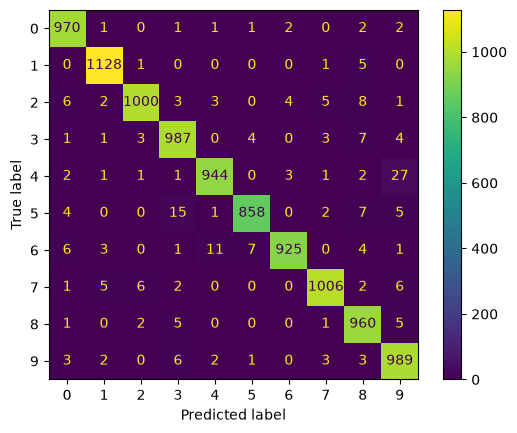

In [23]:
#Confusion Matrix
#Now that we have:y_pred which contains the 10,000 predicted digits, 
# we compare it with:y_test which contains the 10,000 actual digits.

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

Actual 0, predicted 0 → 970 correct
Actual 4, predicted 9 → 27 mistakes
Actual 5, predicted 3 → 15 mistakes

The strong diagonal shows your model is classifying most digits correctly.
27 means 27 images were actually digit 4, but the model predicted them as 9.
15 means 15 images were actually digit 5, but the model predicted them as 3.

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.99      0.96      0.97       892
           6       0.99      0.97      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.96      0.99      0.97       974
           9       0.95      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



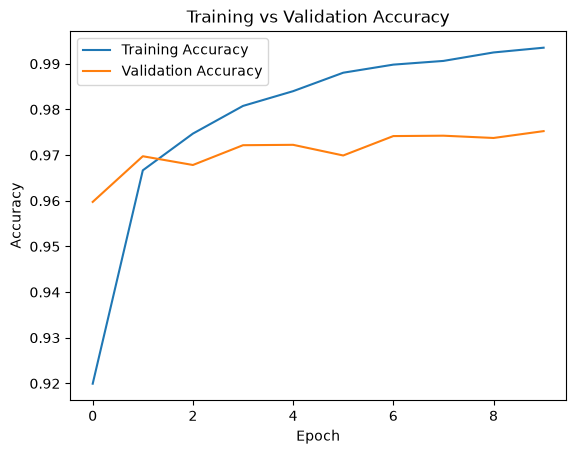

In [28]:
#plot training vs validation accuracy

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

Training accuracy keeps increasing: ~92% → ~99.4%.
Validation accuracy quickly reaches ~97% and then stays around 97–97.5%.
The two curves are fairly close, so there is no severe overfitting.
After around epoch 3–4, validation accuracy mostly stops improving, while training accuracy continues rising slightly.

Main takeaway: the model learns well and generalizes well, but training beyond ~4 epochs gives only small validation improvement.


Graph position 0 = Epoch 1:

Training accuracy ≈ 0.92
Validation accuracy ≈ 0.96

Then the same comparison happens for Epoch 2, 3, ... 10.

10 epochs were plotted; only some epoch numbers are visibly labeled on the x-axis.

history.history['accuracy'] → accuracy after each training epoch.
history.history['val_accuracy'] → accuracy on the validation data after each epoch.
The graph lets us see whether training and validation performance improve together or whether the model starts overfitting.

history.history['accuracy']?
It does NOT give accuracy for each image.
It gives one accuracy value for each epoch.

Since you trained for 10 epochs:

Epoch 1 → accuracy
Epoch 2 → accuracy
Epoch 3 → accuracy
...
Epoch 10 → accuracy

So:
history.history['accuracy']
contains 10 accuracy values.

The 48,000 training images are used to update the weights.
The 12,000 validation images are NOT used to update weights. They are kept aside during training.
After each epoch, the model uses those 12,000 validation images to make predictions and calculate validation loss/accuracy.
Then it goes to the next epoch and continues learning from the 48,000 training images.
The 12,000 validation images act like a temporary test/check set during training, but they are not the final test set.

Training data → trains/updates the model's weights.
Validation data → only checks/predicts performance; it does not train/update weights.

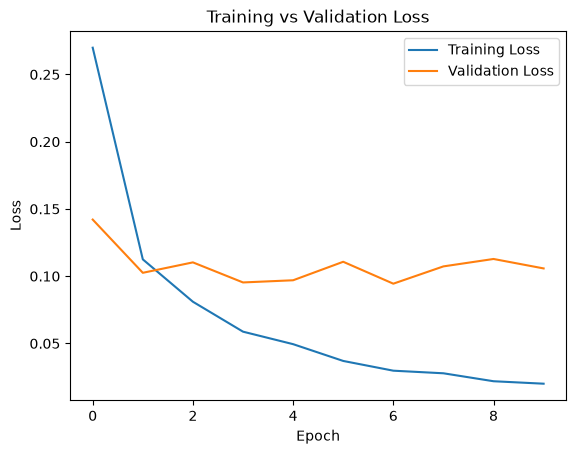

In [29]:
#Training Loss vs Validation Loss.
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

Training loss keeps decreasing → model is learning.
Validation loss decreases initially, then fluctuates around ~0.10 → model is generalizing reasonably well, with some signs that further training gives limited benefit.

history.history['loss'] → stores training loss after each epoch.
history.history['val_loss'] → stores validation loss after each epoch.
If training loss keeps decreasing but validation loss starts increasing, that's a classic sign of overfitting.

Loss measures how wrong the model's predictions are, including how confident those predictions were.